In [ ]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

MEDLAT_THRESHOLD_UM = 3400

# XGBoost model parameters
history_length = 1000
nfilters = int(history_length / time_bs)  # ms

xgb_history = MLencoding(
    tunemodel='xgboost',
    cov_history=True,
    spike_history=False,
    window=time_bs,
    n_filters=nfilters,
    max_time=history_length,
)


In [7]:
import pickle, os

# combos to use
# 25,25,91
# 26,19,113

MOUSE, DAY, TARGET_ID = 26, 19, 113
CACHE_PATH = (
    f'/Users/harryclark/Documents/spatial-manifolds/data/'
    f'gc_ngs_medlat_xgboost_cache/M{MOUSE}_D{DAY}_GC{TARGET_ID}.pkl'
)

if os.path.exists(CACHE_PATH):
    print(f"Loading from cache: {CACHE_PATH}")
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
else:
    # ── Cell classification ───────────────────────────────────────────────────
    gcs, ngs, all_cells = classify_cells_both_sessions(MOUSE, DAY)
    ngs_ids = ngs['cluster_id'].astype(int).tolist()

    # ── Locations ─────────────────────────────────────────────────────────────
    loc_data = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
    loc_data['coord_SCs_x'] = loc_data['coord_SCs_x'] * -1
    loc_sess = loc_data[
        (loc_data['mouse'].astype(int) == MOUSE) &
        (loc_data['day'].astype(int)   == DAY)
    ].copy()
    loc_sess['cluster_id'] = loc_sess['cluster_id'].astype(int)
    loc_sess['medlat'] = np.where(loc_sess['coord_SCs_x'].abs() < MEDLAT_THRESHOLD_UM, 'medial', 'lateral')

    # ── Load session ──────────────────────────────────────────────────────────
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
        MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
        source_path=source_path,
    )
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms'
    ).index[-1]
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

    dt_in_time = np.array(
        beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
        - ((beh['trial_number'][0] - 1) * tl)
    )
    pos_in_time = dt_in_time % tl
    if np.any(np.isnan(pos_in_time)):
        pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl
    trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]

    # ── Neutral cell ──────────────────────────────────────────────────────────
    _gc_id_set  = set(gcs['cluster_id'].astype(int))
    _ngs_id_set = set(ngs['cluster_id'].astype(int))
    ns    = all_cells[~all_cells['cluster_id'].isin(_gc_id_set | _ngs_id_set)].copy().reset_index(drop=True)
    ns_id = int(ns['cluster_id'].values[0])

    target_fr = np.asarray(tcs_time[TARGET_ID])
    T         = len(target_fr)
    pos       = pos_in_time[:T]

    # ── True rate map ─────────────────────────────────────────────────────────
    tc_true = gaussian_filter(
        np.nan_to_num(tcs[TARGET_ID]).astype(np.float64), sigma=2.5
    )[:last_ephys_bin]

    # ── Position-only model ───────────────────────────────────────────────────
    Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(
        pos.reshape(-1, 1), target_fr, verbose=0, continuous_folds=True
    )
    pR2_pos = float(np.nanmean(pR2_cv_pos))
    print(f"pR²(P) = {pR2_pos:.4f}")

    tcs_es_pos, _, _, last_eb, _, _ = compute_vr_tcs_using_expected_spikes(
        MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
        vr_type='VR', source_path=source_path, expected_spikes={ns_id: Y_hat_pos}
    )
    tc_es_pos = gaussian_filter(
        np.nan_to_num(tcs_es_pos[ns_id]).astype(np.float64), sigma=2.5
    )[:last_eb]

    # ── Medial and lateral models ─────────────────────────────────────────────
    recon = {}
    for region, cov_bounds in [('medial', (-np.inf, 3400)), ('lateral', (3400, np.inf))]:
        region_ids = set(
            loc_sess[
                (loc_sess['coord_SCs_x'] >= cov_bounds[0]) &
                (loc_sess['coord_SCs_x'] <  cov_bounds[1])
            ]['cluster_id'].values.astype(int)
        )
        cov_ids = np.array([c for c in ngs_ids if c in region_ids and c in tcs_time])
        if len(cov_ids) == 0:
            print(f"  {region}: no covariate cells")
            recon[region] = None
            continue

        ngs_mat = np.vstack([
            np.pad(np.asarray(tcs_time[c])[:T],
                   (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
                   mode='constant')
            for c in cov_ids
        ]).T
        Y_hat_cov, pR2_cv_cov = xgb_history.fit_cv(
            np.column_stack([pos, ngs_mat]), target_fr, verbose=0, continuous_folds=True
        )
        pR2_cov = float(np.nanmean(pR2_cv_cov))
        print(f"  {region}  pR²(P+NGS, n={len(cov_ids)}) = {pR2_cov:.4f}")

        tcs_es_cov, _, _, _, _, _ = compute_vr_tcs_using_expected_spikes(
            MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
            vr_type='VR', source_path=source_path, expected_spikes={ns_id: Y_hat_cov}
        )
        tc_es_cov = gaussian_filter(
            np.nan_to_num(tcs_es_cov[ns_id]).astype(np.float64), sigma=2.5
        )[:last_eb]
        recon[region] = dict(tc_es=tc_es_cov, pR2=pR2_cov, cov_ids=cov_ids)

    # ── Per-cell delta pR2 ────────────────────────────────────────────────────
    medlat_lookup = dict(zip(loc_sess['cluster_id'], loc_sess['medlat']))
    all_rows = []
    for ngs_id in ngs_ids:
        if ngs_id not in tcs_time:
            continue
        ngs_vec = np.pad(np.asarray(tcs_time[ngs_id])[:T],
                         (0, max(0, T - len(np.asarray(tcs_time[ngs_id])[:T]))),
                         mode='constant')
        _, pR2_pn_cv = xgb_history.fit_cv(
            np.column_stack([pos, ngs_vec]), target_fr, verbose=0, continuous_folds=True
        )
        all_rows.append(dict(
            ngs_cluster_id=ngs_id,
            medlat=medlat_lookup.get(ngs_id, 'unknown'),
            pR2_pos=pR2_pos,
            delta_pr2=float(np.nanmean(pR2_pn_cv)) - pR2_pos,
        ))

    df_t = pd.DataFrame(all_rows).sort_values('delta_pr2', ascending=False).reset_index(drop=True)

    medial_plot_ids  = [c for c in df_t[df_t['medlat'] == 'medial']
                        .sort_values('delta_pr2', ascending=False)['ngs_cluster_id'].astype(int)
                        if c in tcs][:5]
    lateral_plot_ids = [c for c in df_t[df_t['medlat'] == 'lateral']
                        .sort_values('delta_pr2', ascending=False)['ngs_cluster_id'].astype(int)
                        if c in tcs][:5]

    # ── Trial-position maps and smoothed rate maps for top cells ──────────────
    n_pos_bins = int(np.ceil(tl / bs))
    cell_maps, cov_tcs = {}, {}
    for cid in medial_plot_ids + lateral_plot_ids:
        y = np.asarray(tcs_time[cid])
        cell_maps[cid] = build_trial_position_map(
            y, pos_in_time[:len(y)], trial_number_in_time[:len(y)], n_pos_bins
        )
        cov_tcs[cid] = gaussian_filter(
            np.nan_to_num(tcs[cid]).astype(np.float64), sigma=2.5
        )[:last_ephys_bin]

    # ── Save cache ────────────────────────────────────────────────────────────
    cache = dict(
        tc_true=tc_true, tc_es_pos=tc_es_pos, pR2_pos=pR2_pos,
        recon=recon, medial_plot_ids=medial_plot_ids, lateral_plot_ids=lateral_plot_ids,
        cell_maps=cell_maps, cov_tcs=cov_tcs, df_t=df_t,
        last_ephys_bin=last_eb, gcs=gcs, ngs=ngs, all_cells=all_cells,
    )
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(cache, f)
    print(f"Saved → {CACHE_PATH}")

# Unpack
tc_true          = cache['tc_true']
tc_es_pos        = cache['tc_es_pos']
pR2_pos          = cache['pR2_pos']
recon            = cache['recon']
medial_plot_ids  = cache['medial_plot_ids']
lateral_plot_ids = cache['lateral_plot_ids']
cell_maps        = cache['cell_maps']
cov_tcs          = cache['cov_tcs']
df_t             = cache['df_t']
last_ephys_bin   = cache['last_ephys_bin']
gcs              = cache['gcs']
ngs              = cache['ngs']
all_cells        = cache['all_cells']


pR²(P) = 0.0400
using expected spikes for cell 38
  medial  pR²(P+NGS, n=64) = 0.2640
using expected spikes for cell 38
  lateral  pR²(P+NGS, n=149) = 0.0839
using expected spikes for cell 38
Saved → /Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_medlat_xgboost_cache/M26_D19_GC113.pkl


hi
hi



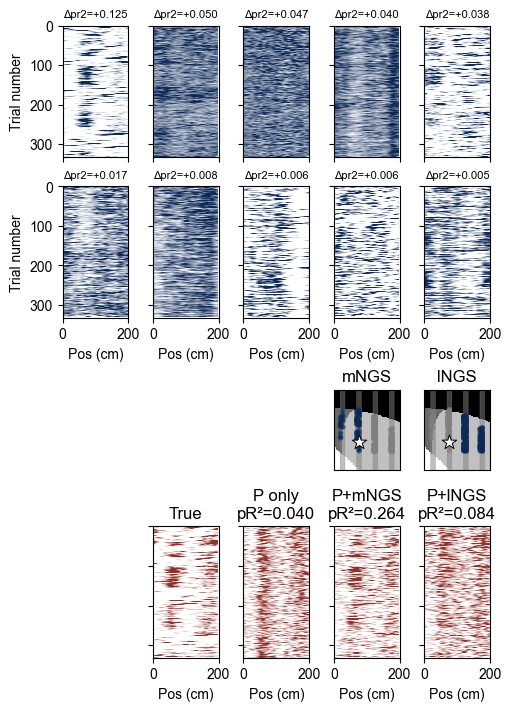

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_5_xgboost_medlat/combined_GC113_M26_D19.pdf


In [12]:
from matplotlib.patches import Circle

fig, axs = plt.subplots(
    4, 5,
    figsize=(5, 7),
    constrained_layout=True,
    width_ratios=[1, 1, 1, 1, 1],
    height_ratios=[1.3, 1.3, 1, 1.3],
    sharey='row'
)

# ── Rows 0-1: top NGS covariate rate maps ────────────────────────────────────
def _draw_cov_row(ids, row):
    for col in range(5):
        ax_ = axs[row, col]
        if col >= len(ids):
            ax_.axis('off')
            continue
        cid = ids[col]
        plot_firing_rate_map(ax_, cov_tcs[cid], bs=bs, tl=tl, p=95,
                             sort_indices=None, cmap=white_to_hex_cmap('#0d2958'))
        row_d = df_t[df_t['ngs_cluster_id'] == cid]
        d = float(row_d['delta_pr2'].iloc[0]) if len(row_d) else np.nan
        ax_.set_title(f'Δpr2={d:+.3f}', fontsize=8)
        if col == 0:
            ax_.set_ylabel('Trial number')
        
        if row == 1:
            ax_.set_xlabel('Pos (cm)')
        elif row == 0:
            ax_.set_xticklabels([])

_draw_cov_row(medial_plot_ids,  row=0)
_draw_cov_row(lateral_plot_ids, row=1)

# ── Row 2: probe anatomy ──────────────────────────────────────────────────────
annotations, annotation_colors, xs, ys = make_annotations(
    MOUSE, path='/Users/harryclark/Documents/spatial-manifolds/data'
)

def _draw_anatomy(ax_):
    for col_ in np.unique(annotation_colors):
        bp = extract_border(annotation_colors, col_, only_border=False)
        ax_.scatter(xs[bp[:, 1]], ys[bp[:, 0]], color=col_, s=1, rasterized=True)
    plot_NP2_probe(ax_, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
                   probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    for sp in ax_.spines.values():
        sp.set_visible(True)

for off_col in [0, 1, 2]:
    axs[2, off_col].axis('off')

for col, region in zip([3, 4], ['medial', 'lateral']):
    ax_p = axs[2, col]
    _draw_anatomy(ax_p)
    ax_p.scatter(ngs['probe_x'].values, ngs['probe_y'].values, marker='o', color='grey', alpha=0.4, s=7)
    ax_p.scatter(gcs['probe_x'].values, gcs['probe_y'].values, marker='o', color='grey', alpha=0.4, s=7)
    tgt_row = all_cells[all_cells['cluster_id'] == TARGET_ID]
    if not tgt_row.empty:
        ax_p.scatter(tgt_row['probe_x'].values[0], tgt_row['probe_y'].values[0],
                     marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=100)
    if recon.get(region) is not None:
        for cov_cid in recon[region]['cov_ids']:
            cr = all_cells[all_cells['cluster_id'] == cov_cid]
            if not cr.empty:
                ax_p.add_patch(Circle(
                    (cr['probe_x'].values[0], cr['probe_y'].values[0]),
                    radius=20, edgecolor='#0d2958', facecolor='#0d2958', lw=2, alpha=0.6, zorder=12
                ))
    ax_p.set_ylim([np.min(all_cells['probe_y'].values) - 300,
                   np.max(all_cells['probe_y'].values) + 300])
    ax_p.set_xlim([-100, 900])
    ax_p.set_title('mNGS' if region == 'medial' else 'lNGS')

# ── Row 3: reconstructed rate maps ────────────────────────────────────────────
rate_data = [
    (tc_true,   'True',                                   white_to_hex_cmap('#90312a')),
    (tc_es_pos, f'P only\npR²={pR2_pos:.3f}',            white_to_hex_cmap('#90312a')),
    (recon['medial']['tc_es']  if recon.get('medial')  else None,
     f'P+mNGS\npR²={recon["medial"]["pR2"]:.3f}'  if recon.get('medial')  else 'P+mNGS\n(n/a)',
     white_to_hex_cmap('#90312a')),
    (recon['lateral']['tc_es'] if recon.get('lateral') else None,
     f'P+lNGS\npR²={recon["lateral"]["pR2"]:.3f}' if recon.get('lateral') else 'P+lNGS\n(n/a)',
     white_to_hex_cmap('#90312a')),
]

axs[3, 0].axis('off')
for col, (tc_data, title, cmap_) in enumerate(rate_data):
    ax_r = axs[3, col + 1]
    if tc_data is not None:
        plot_firing_rate_map(ax_r, tc_data, bs=bs, tl=tl, p=95, sort_indices=None, cmap=cmap_)
    else:
        ax_r.axis('off')
    ax_r.set_title(title)
    if col == 0:
        print('')
    else:
        ax_r.set_yticklabels([])
    ax_r.set_xlabel('Pos (cm)')

save_path = (
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_5_xgboost_medlat/combined_GC{TARGET_ID}_M{MOUSE}_D{DAY}.pdf'
)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")


hi
hi
hi


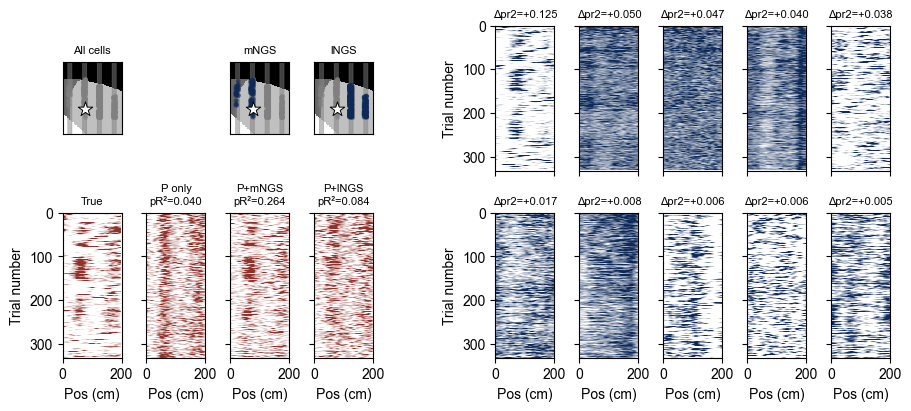

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/combined_GC113_M26_D19_v2.pdf


In [17]:
from matplotlib.patches import Circle

fig, axs = plt.subplots(
    2, 10,
    figsize=(9, 4),
    constrained_layout=True,
    width_ratios=[1, 1, 1, 1, 0.7, 1, 1, 1, 1, 1],
    height_ratios=[1, 1],
)

# ── Spacer column ─────────────────────────────────────────────────────────────
for row in range(2):
    axs[row, 4].axis('off')

# ── Anatomy helper ────────────────────────────────────────────────────────────
annotations_a, ann_colors_a, xs_a, ys_a = make_annotations(
    MOUSE, path='/Users/harryclark/Documents/spatial-manifolds/data'
)
min_y_ = np.min(all_cells['probe_y'].values) - 300
max_y_ = np.max(all_cells['probe_y'].values) + 300
tgt_row = all_cells[all_cells['cluster_id'] == TARGET_ID]

def _draw_anatomy(ax_):
    for col_ in np.unique(ann_colors_a):
        bp = extract_border(ann_colors_a, col_, only_border=False)
        ax_.scatter(xs_a[bp[:, 1]], ys_a[bp[:, 0]], color=col_, s=1, rasterized=True)
    plot_NP2_probe(ax_, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa',
                   probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    for sp in ax_.spines.values():
        sp.set_visible(True)
    ax_.set_ylim([min_y_, max_y_])
    ax_.set_xlim([-100, 900])

def _add_target_star(ax_):
    if not tgt_row.empty:
        ax_.scatter(tgt_row['probe_x'].values[0], tgt_row['probe_y'].values[0],
                    marker='*', s=120, color='white', edgecolor='black',
                    linewidth=0.7, zorder=100)

# ── Row 0, Col 0: all cells + star ───────────────────────────────────────────
_draw_anatomy(axs[0, 0])
axs[0, 0].scatter(all_cells['probe_x'].values, all_cells['probe_y'].values,
                  marker='o', color='grey', alpha=0.4, s=7)
_add_target_star(axs[0, 0])
axs[0, 0].set_title('All cells', fontsize=8)

# ── Row 0, Col 1: blank (above P-only) ────────────────────────────────────────
axs[0, 1].axis('off')

# ── Row 0, Cols 2-3: medial / lateral probe ───────────────────────────────────
for col, region in zip([2, 3], ['medial', 'lateral']):
    ax_p = axs[0, col]
    _draw_anatomy(ax_p)
    ax_p.scatter(ngs['probe_x'].values, ngs['probe_y'].values,
                 marker='o', color='grey', alpha=0.4, s=7)
    ax_p.scatter(gcs['probe_x'].values, gcs['probe_y'].values,
                 marker='o', color='grey', alpha=0.4, s=7)
    _add_target_star(ax_p)
    if recon.get(region) is not None:
        for cov_cid in recon[region]['cov_ids']:
            cr = all_cells[all_cells['cluster_id'] == cov_cid]
            if not cr.empty:
                ax_p.add_patch(Circle(
                    (cr['probe_x'].values[0], cr['probe_y'].values[0]),
                    radius=20, edgecolor='#0d2958', facecolor='#0d2958',
                    lw=2, alpha=0.6, zorder=12
                ))
    ax_p.set_title('mNGS' if region == 'medial' else 'lNGS', fontsize=8)
    ax_p.set_yticklabels([])

# ── Row 1, Cols 0-3: reconstructed rate maps ──────────────────────────────────
rate_data = [
    (tc_true,   'True',                                        white_to_hex_cmap('#90312a')),
    (tc_es_pos, f'P only\npR²={pR2_pos:.3f}',                 white_to_hex_cmap('#90312a')),
    (recon['medial']['tc_es']  if recon.get('medial')  else None,
     f'P+mNGS\npR²={recon["medial"]["pR2"]:.3f}'  if recon.get('medial')  else 'P+mNGS\n(n/a)',
     white_to_hex_cmap('#90312a')),
    (recon['lateral']['tc_es'] if recon.get('lateral') else None,
     f'P+lNGS\npR²={recon["lateral"]["pR2"]:.3f}' if recon.get('lateral') else 'P+lNGS\n(n/a)',
     white_to_hex_cmap('#90312a')),
]

for col, (tc_data, title, cmap_) in enumerate(rate_data):
    ax_r = axs[1, col]
    if tc_data is not None:
        plot_firing_rate_map(ax_r, tc_data, bs=bs, tl=tl, p=95,
                             sort_indices=None, cmap=cmap_)
    else:
        ax_r.axis('off')
    ax_r.set_title(title, fontsize=8)
    if col == 0:
        ax_r.set_ylabel('Trial number')
    else:
        ax_r.set_yticklabels([])
    ax_r.set_xlabel('Pos (cm)')

# ── Cols 5-9: NGS trial-position maps (row 0 = medial, row 1 = lateral) ───────
def _draw_cov_row(ids, row):
    for i in range(5):
        ax_ = axs[row, i + 5]
        if i >= len(ids):
            ax_.axis('off')
            continue
        cid = ids[i]
        plot_firing_rate_map(ax_, cov_tcs[cid], bs=bs, tl=tl, p=95,
                             sort_indices=None, cmap=white_to_hex_cmap('#0d2958'))
        row_d = df_t[df_t['ngs_cluster_id'] == cid]
        d = float(row_d['delta_pr2'].iloc[0]) if len(row_d) else np.nan
        ax_.set_title(f'Δpr2={d:+.3f}', fontsize=8)
        if i == 0:
            ax_.set_ylabel('Trial number')
        else:
            ax_.set_yticklabels([])
        if row == 0:
            ax_.set_xticklabels([])
        else:
            ax_.set_xlabel('Pos (cm)')


_draw_cov_row(medial_plot_ids,  row=0)
_draw_cov_row(lateral_plot_ids, row=1)

save_path = (
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_4_xgboost/combined_GC{TARGET_ID}_M{MOUSE}_D{DAY}_v2.pdf'
)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")


In [ ]:
# Requires tcs_time and pos_in_time to be loaded (run session load snippet first)
target_fr = np.asarray(tcs_time[TARGET_ID])
T         = len(target_fr)
pos       = pos_in_time[:T]

# Pos only
y_hat_pos, _ = xgb_history.fit_cv(
    pos.reshape(-1, 1), target_fr, verbose=0, continuous_folds=True
)

# Per region
y_hats = {}
for region in ['medial', 'lateral']:
    if recon.get(region) is None:
        y_hats[region] = None
        continue
    cov_ids = recon[region]['cov_ids']
    ngs_mat = np.vstack([
        np.pad(np.asarray(tcs_time[c])[:T],
               (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
               mode='constant')
        for c in cov_ids if c in tcs_time
    ]).T
    y_hat, _ = xgb_history.fit_cv(
        np.column_stack([pos, ngs_mat]), target_fr, verbose=0, continuous_folds=True
    )
    y_hats[region] = y_hat

# All NGS combined
all_ngs_ids = [
    c for c in (
        list(recon['medial']['cov_ids']  if recon.get('medial')  else []) +
        list(recon['lateral']['cov_ids'] if recon.get('lateral') else [])
    ) if c in tcs_time
]
all_ngs_mat = np.vstack([
    np.pad(np.asarray(tcs_time[c])[:T],
           (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
           mode='constant')
    for c in all_ngs_ids
]).T
y_hat_all, _ = xgb_history.fit_cv(
    np.column_stack([pos, all_ngs_mat]), target_fr, verbose=0, continuous_folds=True
)

print("Y_hat predictions computed.")


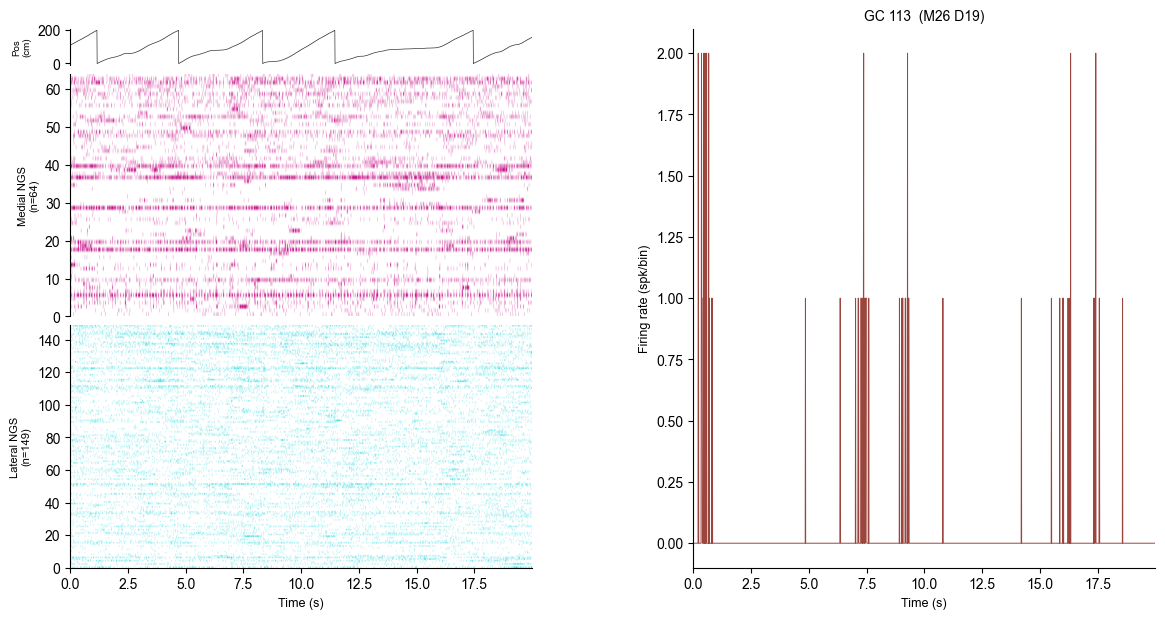

In [18]:
import matplotlib.gridspec as gridspec

# ── Time window (adjust N_BINS to show more/less of the session) ──────────────
N_BINS = 2000
t = np.arange(N_BINS) * (time_bs / 1000)  # seconds

# ── Collect traces ─────────────────────────────────────────────────────────────
pos_trace = pos_in_time[:N_BINS]
gc_trace  = np.asarray(tcs_time[TARGET_ID])[:N_BINS]

med_cids = list(recon['medial']['cov_ids'])  if recon.get('medial')  else []
lat_cids = list(recon['lateral']['cov_ids']) if recon.get('lateral') else []

def _stack(cids):
    return np.vstack([
        np.asarray(tcs_time[c])[:N_BINS]
        for c in cids if c in tcs_time
    ])

med_mat = _stack(med_cids)  # (n_medial, N_BINS)
lat_mat = _stack(lat_cids)  # (n_lateral, N_BINS)

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7))
gs_outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35, width_ratios=[1, 1])

gs_left = gridspec.GridSpecFromSubplotSpec(
    3, 1,
    subplot_spec=gs_outer[0],
    hspace=0.05,
    height_ratios=[0.15, 1, 1],
)
ax_pos = fig.add_subplot(gs_left[0])
ax_med = fig.add_subplot(gs_left[1])
ax_lat = fig.add_subplot(gs_left[2])
ax_gc  = fig.add_subplot(gs_outer[1])

# ── Position trace ─────────────────────────────────────────────────────────────
ax_pos.plot(t, pos_trace, color='#333333', lw=0.5)
ax_pos.set_ylabel('Pos\n(cm)', fontsize=7)
ax_pos.set_xlim([t[0], t[-1]])
ax_pos.set_xticklabels([])
ax_pos.tick_params(bottom=False)
for sp in ['top', 'right', 'bottom']:
    ax_pos.spines[sp].set_visible(False)

# ── Medial NGS heatmap ─────────────────────────────────────────────────────────
ax_med.imshow(
    med_mat, aspect='auto', origin='lower',
    cmap=white_to_hex_cmap('#C50E85'),
    extent=[t[0], t[-1], 0, med_mat.shape[0]],
    vmin=np.nanpercentile(med_mat, 5),
    vmax=np.nanpercentile(med_mat, 95),
)
ax_med.set_ylabel(f'Medial NGS\n(n={len(med_cids)})', fontsize=8)
ax_med.set_xticklabels([])
ax_med.tick_params(bottom=False)
for sp in ['top', 'right', 'bottom']:
    ax_med.spines[sp].set_visible(False)

# ── Lateral NGS heatmap ────────────────────────────────────────────────────────
ax_lat.imshow(
    lat_mat, aspect='auto', origin='lower',
    cmap=white_to_hex_cmap('#29d8de'),
    extent=[t[0], t[-1], 0, lat_mat.shape[0]],
    vmin=np.nanpercentile(lat_mat, 5),
    vmax=np.nanpercentile(lat_mat, 95),
)
ax_lat.set_ylabel(f'Lateral NGS\n(n={len(lat_cids)})', fontsize=8)
ax_lat.set_xlabel('Time (s)', fontsize=9)
for sp in ['top', 'right']:
    ax_lat.spines[sp].set_visible(False)

# ── GC firing rate trace ───────────────────────────────────────────────────────
ax_gc.plot(t, gc_trace, color='#90312a', lw=0.7, alpha=0.9)
ax_gc.set_ylabel('Firing rate (spk/bin)', fontsize=9)
ax_gc.set_xlabel('Time (s)', fontsize=9)
ax_gc.set_xlim([t[0], t[-1]])
ax_gc.set_title(f'GC {TARGET_ID}  (M{MOUSE} D{DAY})', fontsize=10)
for sp in ['top', 'right']:
    ax_gc.spines[sp].set_visible(False)

plt.savefig(
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_4_xgboost/time_traces_GC{TARGET_ID}_M{MOUSE}_D{DAY}.pdf',
    dpi=300, bbox_inches='tight'
)
plt.show()


In [20]:
target_fr = np.asarray(tcs_time[TARGET_ID])
T         = len(target_fr)
pos       = pos_in_time[:T]

# Pos only
y_hat_pos, _ = xgb_history.fit_cv(
    pos.reshape(-1, 1), target_fr, verbose=0, continuous_folds=True
)

# Per region: NGS-only and Pos+NGS
y_hat_ngs_only = {}
y_hat_pos_ngs  = {}
ngs_mats       = {}

for region in ['medial', 'lateral']:
    if recon.get(region) is None:
        y_hat_ngs_only[region] = None
        y_hat_pos_ngs[region]  = None
        continue
    cov_ids = recon[region]['cov_ids']
    ngs_mat = np.vstack([
        np.pad(np.asarray(tcs_time[c])[:T],
               (0, max(0, T - len(np.asarray(tcs_time[c])[:T]))),
               mode='constant')
        for c in cov_ids if c in tcs_time
    ]).T
    ngs_mats[region] = ngs_mat

    y_ngs, _ = xgb_history.fit_cv(
        ngs_mat, target_fr, verbose=0, continuous_folds=True
    )
    y_pos_ngs, _ = xgb_history.fit_cv(
        np.column_stack([pos, ngs_mat]), target_fr, verbose=0, continuous_folds=True
    )
    y_hat_ngs_only[region] = y_ngs
    y_hat_pos_ngs[region]  = y_pos_ngs


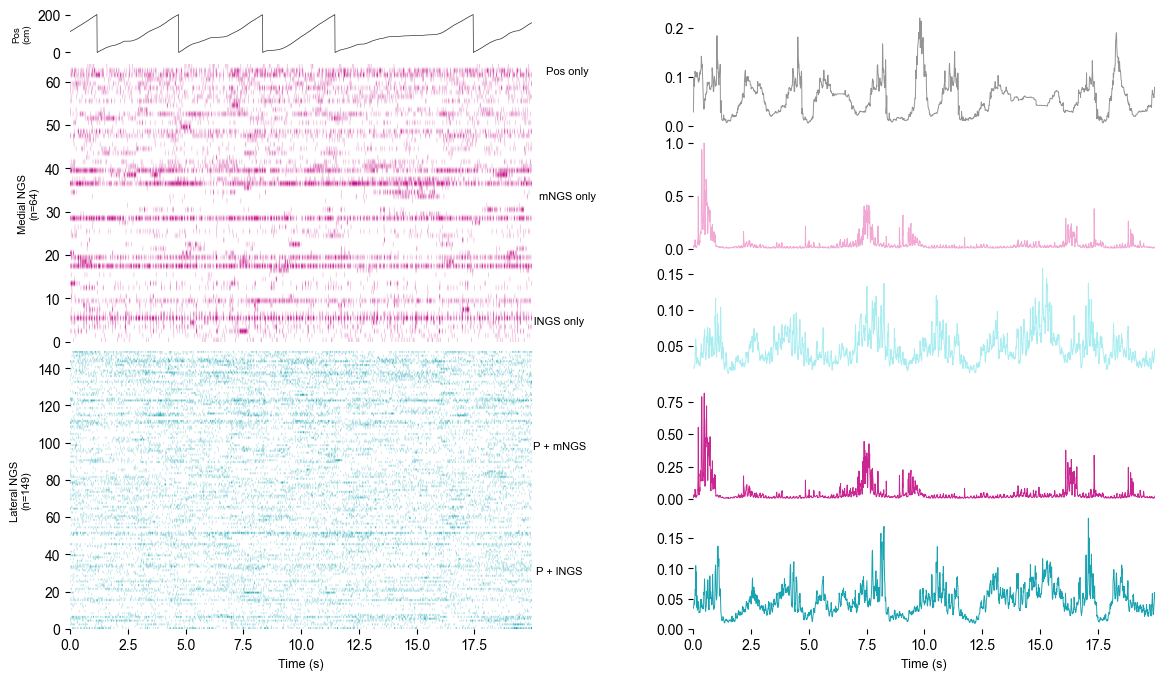

In [21]:
import matplotlib.gridspec as gridspec

N_BINS = 2000
t = np.arange(N_BINS) * (time_bs / 1000)

pos_trace = pos_in_time[:N_BINS]
med_mat   = ngs_mats['medial'][:N_BINS].T   if 'medial'  in ngs_mats else np.empty((0, N_BINS))
lat_mat   = ngs_mats['lateral'][:N_BINS].T  if 'lateral' in ngs_mats else np.empty((0, N_BINS))

gc_traces = [
    (y_hat_pos[:N_BINS],                  'Pos only',    '#888888'),
    (y_hat_ngs_only['medial'][:N_BINS],   'mNGS only',   '#f0a0d0'),
    (y_hat_ngs_only['lateral'][:N_BINS],  'lNGS only',   '#a0ecf0'),
    (y_hat_pos_ngs['medial'][:N_BINS],    'P + mNGS',    '#C50E85'),
    (y_hat_pos_ngs['lateral'][:N_BINS],   'P + lNGS',    '#0099a8'),
]

def _clean(ax):
    for sp in ax.spines.values():
        sp.set_visible(False)

fig = plt.figure(figsize=(14, 8))
gs_outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35, width_ratios=[1, 1])

gs_left = gridspec.GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs_outer[0],
    hspace=0.05, height_ratios=[0.15, 1, 1],
)
ax_pos = fig.add_subplot(gs_left[0])
ax_med = fig.add_subplot(gs_left[1])
ax_lat = fig.add_subplot(gs_left[2])

gs_right = gridspec.GridSpecFromSubplotSpec(
    5, 1, subplot_spec=gs_outer[1], hspace=0.08,
)
ax_gc = [fig.add_subplot(gs_right[i]) for i in range(5)]

# Position trace
ax_pos.plot(t, pos_trace, color='#333333', lw=0.5)
ax_pos.set_ylabel('Pos\n(cm)', fontsize=7)
ax_pos.set_xlim([t[0], t[-1]])
ax_pos.set_xticklabels([])
ax_pos.tick_params(bottom=False)
_clean(ax_pos)

# Medial NGS heatmap
ax_med.imshow(
    med_mat, aspect='auto', origin='lower',
    cmap=white_to_hex_cmap('#C50E85'),
    extent=[t[0], t[-1], 0, med_mat.shape[0]],
    vmin=np.nanpercentile(med_mat, 5) if med_mat.size else 0,
    vmax=np.nanpercentile(med_mat, 95) if med_mat.size else 1,
)
ax_med.set_ylabel(f'Medial NGS\n(n={med_mat.shape[0]})', fontsize=8)
ax_med.set_xticklabels([])
ax_med.tick_params(bottom=False)
_clean(ax_med)

# Lateral NGS heatmap
ax_lat.imshow(
    lat_mat, aspect='auto', origin='lower',
    cmap=white_to_hex_cmap('#0099a8'),
    extent=[t[0], t[-1], 0, lat_mat.shape[0]],
    vmin=np.nanpercentile(lat_mat, 5) if lat_mat.size else 0,
    vmax=np.nanpercentile(lat_mat, 95) if lat_mat.size else 1,
)
ax_lat.set_ylabel(f'Lateral NGS\n(n={lat_mat.shape[0]})', fontsize=8)
ax_lat.set_xlabel('Time (s)', fontsize=9)
_clean(ax_lat)

# GC predictions
for i, (trace, label, color) in enumerate(gc_traces):
    ax_gc[i].plot(t, trace, color=color, lw=0.7, alpha=0.9)
    ax_gc[i].set_ylabel(label, fontsize=8, rotation=0, labelpad=70, va='center')
    ax_gc[i].set_xlim([t[0], t[-1]])
    _clean(ax_gc[i])
    if i < 4:
        ax_gc[i].set_xticklabels([])
        ax_gc[i].tick_params(bottom=False)
    else:
        ax_gc[i].set_xlabel('Time (s)', fontsize=9)

plt.savefig(
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_4_xgboost/time_traces_GC{TARGET_ID}_M{MOUSE}_D{DAY}.pdf',
    dpi=300, bbox_inches='tight'
)
plt.show()


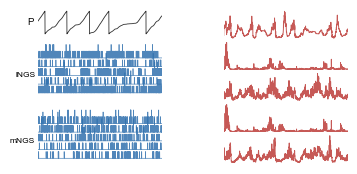

In [51]:
import matplotlib.gridspec as gridspec

N_BINS  = 2000
N_CELLS = 5
t = np.arange(N_BINS) * (time_bs / 1000)

pos_trace = pos_in_time[:N_BINS]

med_full = ngs_mats['medial'][:N_BINS].T  if 'medial'  in ngs_mats else np.empty((0, N_BINS))
lat_full = ngs_mats['lateral'][:N_BINS].T if 'lateral' in ngs_mats else np.empty((0, N_BINS))
n_med    = min(N_CELLS, med_full.shape[0])
n_lat    = min(N_CELLS, lat_full.shape[0])
med_mat  = med_full[:n_med]
lat_mat  = lat_full[:n_lat]

gc_traces = [
    (y_hat_pos[:N_BINS],                  '',   '#c04744'),
    (y_hat_ngs_only['medial'][:N_BINS],   '',  '#c04744'),
    (y_hat_ngs_only['lateral'][:N_BINS],  '',  '#c04744'),
    (y_hat_pos_ngs['medial'][:N_BINS],    '',   "#c04744"),
    (y_hat_pos_ngs['lateral'][:N_BINS],   '',   '#c04744'),
]

NGS_COLOR = "#3171ae"

def _clean(ax):
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Step = 1.5× the per-cell peak so there is clear space between adjacent traces
per_cell_peak = np.nanmax([
    np.nanpercentile(med_mat, 99) if n_med > 0 else 0,
    np.nanpercentile(lat_mat, 99) if n_lat > 0 else 0,
])
step = per_cell_peak * 1.3
gap  = step * 2.5

fig = plt.figure(figsize=(4, 2))
gs_outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.5, width_ratios=[1, 1])
gs_left  = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs_outer[0], hspace=0.05, height_ratios=[0.2, 1],
)
gs_right = gridspec.GridSpecFromSubplotSpec(
    5, 1, subplot_spec=gs_outer[1], hspace=0.05,
)

ax_pos = fig.add_subplot(gs_left[0])
ax_ngs = fig.add_subplot(gs_left[1])
ax_gc  = [fig.add_subplot(gs_right[i]) for i in range(5)]

# Position trace
ax_pos.plot(t, pos_trace, color='#333333', lw=0.6)
ax_pos.set_ylabel('P', fontsize=7, rotation=0, labelpad=5, va='center')
ax_pos.set_xlim([t[0], t[-1]])
_clean(ax_pos)

# Stacked NGS traces — medial group
offset = 0.0
for i in range(n_med):
    ax_ngs.plot(t, med_mat[i] + offset, color=NGS_COLOR, lw=0.5, alpha=0.85)
    if i == 2:
        ax_ngs.text(-0.02, offset, 'mNGS', fontsize=6, ha='right', va='center',
                    transform=ax_ngs.get_yaxis_transform())
    offset += step

# Gap between groups
offset += gap

# Lateral group
for i in range(n_lat):
    ax_ngs.plot(t, lat_mat[i] + offset, color=NGS_COLOR, lw=0.5, alpha=0.85)
    if i == 2:
        ax_ngs.text(-0.02, offset, 'lNGS', fontsize=6, ha='right', va='center',
                    transform=ax_ngs.get_yaxis_transform())
    offset += step

ax_ngs.set_xlim([t[0], t[-1]])
_clean(ax_ngs)

# GC predictions
for i, (trace, label, color) in enumerate(gc_traces):
    ax_gc[i].plot(t, trace, color=color, lw=0.7, alpha=0.9)
    ax_gc[i].set_ylabel(label, fontsize=7, rotation=0, labelpad=20, va='center')
    ax_gc[i].set_xlim([t[0], t[-1]])
    _clean(ax_gc[i])

plt.savefig(
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    f'figure_5_xgboost_medlat/time_traces_GC{TARGET_ID}_M{MOUSE}_D{DAY}.pdf',
    dpi=300, bbox_inches='tight'
)
plt.show()
